# Loading libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier,XGBRegressor, DMatrix
from sklearn.metrics import silhouette_score, accuracy_score, classification_report, confusion_matrix, mean_absolute_error, mean_squared_error
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

## Loading the data


In [2]:
data = pd.read_csv('/Users/iliadioleti/Downloads/Dataset/train.csv')

In [3]:
data.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration'],
      dtype='object')

In [4]:
data_weather = pd.read_csv('/Users/iliadioleti/Downloads/Dataset/weather_data_nyc_centralpark_2016.csv')

In [5]:
test = pd.read_csv('/Users/iliadioleti/Downloads/Dataset/test.csv')

In [6]:
test.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'passenger_count',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'store_and_fwd_flag'],
      dtype='object')

## Dataset exploration

In [7]:
def explore_initial(df):

    # 1. General info

    print(f"Dataset Shape: {df.shape}")
    print("\nBasic Info:")
    print(df.info())
    print("\nMissing Values per Column:")
    print(df.isnull().sum())

    # Display first few rows
    print("\nFirst 5 Rows of the Data:")
    print(df.head())

    # 2. Data exploration and handling based on column types
    for col in df.columns:
        print(f"\n--- Exploring Column: {col} ---")
        col_data = df[col]

        # If column is numeric
        if pd.api.types.is_numeric_dtype(col_data):
            print(f"{col} is numeric.")
            print(col_data.describe())

        # If column is categorical
        elif pd.api.types.is_categorical_dtype(col_data) or df[col].nunique() < 15:
            print(f"{col} is categorical.")
            print(col_data.value_counts())

        # If column is datetime
        elif pd.api.types.is_datetime64_any_dtype(col_data):
            print(f"{col} is datetime.")
            # Extract useful features
            df[f'{col}_hour'] = col_data.dt.hour
            df[f'{col}_day_of_week'] = col_data.dt.dayofweek
            print(f"Extracted hour and day_of_week from {col}.")

            # Visualize day of week
            plt.figure(figsize=(8, 5))
            sns.countplot(df[f'{col}_day_of_week'])
            plt.title(f'Distribution of Day of Week for {col}')
            plt.show()

explore_initial(data)

Dataset Shape: (1458644, 11)

Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB
None

Missing Values per Column:
id                    0
vendor_id             0
pickup_datetime       0
dropoff_datet

/var/folders/1z/9l74yfvx0j31d5v75zchygwc0000gn/T/ipykernel_7494/2112526733.py:26: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(col_data) or df[col].nunique() < 15:
/var/folders/1z/9l74yfvx0j31d5v75zchygwc0000gn/T/ipykernel_7494/2112526733.py:26: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(col_data) or df[col].nunique() < 15:



--- Exploring Column: vendor_id ---
vendor_id is numeric.
count    1.458644e+06
mean     1.534950e+00
std      4.987772e-01
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      2.000000e+00
max      2.000000e+00
Name: vendor_id, dtype: float64

--- Exploring Column: pickup_datetime ---

--- Exploring Column: dropoff_datetime ---

--- Exploring Column: passenger_count ---
passenger_count is numeric.
count    1.458644e+06
mean     1.664530e+00
std      1.314242e+00
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      9.000000e+00
Name: passenger_count, dtype: float64

--- Exploring Column: pickup_longitude ---
pickup_longitude is numeric.
count    1.458644e+06
mean    -7.397349e+01
std      7.090186e-02
min     -1.219333e+02
25%     -7.399187e+01
50%     -7.398174e+01
75%     -7.396733e+01
max     -6.133553e+01
Name: pickup_longitude, dtype: float64

--- Exploring Column: pickup_latitude ---
pickup_latitude is numeric.
co

/var/folders/1z/9l74yfvx0j31d5v75zchygwc0000gn/T/ipykernel_7494/2112526733.py:26: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(col_data) or df[col].nunique() < 15:


In [8]:
data.describe(include = 'all')

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
count,1458644,1.458644e+06,1458644,1458644,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1458644,1.458644e+06
unique,1458644,NaN,1380222,1380377,NaN,NaN,NaN,NaN,NaN,2,NaN
top,id2875421,NaN,2016-03-04 08:07:34,2016-02-19 19:25:04,NaN,NaN,NaN,NaN,NaN,N,NaN
freq,1,NaN,5,5,NaN,NaN,NaN,NaN,NaN,1450599,NaN
mean,NaN,1.534950e+00,NaN,NaN,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,NaN,9.594923e+02
std,NaN,4.987772e-01,NaN,NaN,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,NaN,5.237432e+03
min,NaN,1.000000e+00,NaN,NaN,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,NaN,1.000000e+00
25%,NaN,1.000000e+00,NaN,NaN,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,NaN,3.970000e+02
50%,NaN,2.000000e+00,NaN,NaN,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,NaN,6.620000e+02
75%,NaN,2.000000e+00,NaN,NaN,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,NaN,1.075000e+03


### Insights from this initial check/summary of the data



*   Shape: The dataset contains 1,458,644 rows and 11 columns. It is quite large, indicating substantial data to analyze.
*  No missing data!
*   The trip_duration has a wide range, with a mean of 833.79 seconds (~14 minutes) and a maximum of 3,440 seconds (~57 minutes). This suggests the trips vary significantly in duration.
* There are outliers, as the minimum duration is 1 second, which is unrealistic and should be investigated further.
*  The column vendor_id has two unique values (1 and 2). This likely corresponds to two different taxi service providers, with the majority split roughly evenly between the two.
* The mean number of passengers is 1.66, with a maximum of 6. Most trips have 1 or 2 passengers, as shown by the median and interquartile range.
* There are some records with 0 passengers, which should be investigated for possible data errors.
* Geospatial data: There are some extreme values (e.g., a minimum longitude of -121.93, which is far outside NYC), which may need further cleaning. NOT SURE ABOUT THIS.
* The store_and_fwd_flag is mostly 'N' (meaning trips are not stored and forwarded), with 8,045 instances of 'Y' (trips temporarily stored before being sent to the server). This may indicate data transfer issues during those trips.
* Both pickup_datetime and dropoff_datetime columns are in object format and will need to be converted to datetime types for analysis.





## Data Preprocessing and Outlier removal

Testing changes: made quantiles 10-90, also stopped capping the passenger count, removed pickup dropoff location cleanup

In [9]:
# 1. Convert pickup and dropoff datetime columns to datetime format
data['pickup_datetime'] = pd.to_datetime(data['pickup_datetime'])
data['dropoff_datetime'] = pd.to_datetime(data['dropoff_datetime'])

# 2. Handle passenger count: Remove rows where passenger_count is 0 or NaN
data = data[(data['passenger_count'] > 0)]

# 3. Handle trip duration outliers:
# Calculate Q1 (25th percentile) and Q3 (75th percentile) for trip_duration
Q1 = data['trip_duration'].quantile(0.10)
Q3 = data['trip_duration'].quantile(0.90)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the data to keep only rows within the IQR range for trip_duration
data = data[(data['trip_duration'] >= lower_bound) & (data['trip_duration'] <= upper_bound)]


## Feature engineering

In [10]:
# Extract time-related features from pickup_datetime
data['pickup_hour'] = data['pickup_datetime'].dt.hour
data['pickup_day_of_week'] = data['pickup_datetime'].dt.dayofweek  # Monday=0, Sunday=6
data['pickup_month'] = data['pickup_datetime'].dt.month

In [11]:
#encoding categorical columns
categorical_features = ['store_and_fwd_flag','vendor_id']
for feature in categorical_features:
  dummies = pd.get_dummies(data[feature], prefix=feature)
  data = pd.concat([data, dummies], axis=1)
  data.drop([feature], axis=1, inplace=True)


In [12]:
#Manhattan Distance
def manhattan_distance(lat_1, lng_1, lat_2, lng_2):
  lat_1, lng_1, lat_2, lng_2 = map(np.radians, (lat_1, lng_1, lat_2, lng_2))
  AVG_EARTH_RADIUS = 6371
  dlat = lat_2 - lat_1
  dlng = lng_2 - lng_1
  lat_dist = AVG_EARTH_RADIUS * dlat
  lng_dist = AVG_EARTH_RADIUS * np.cos((lat_1 + lat_2) / 2) * dlng
  return abs(lat_dist) + abs(lng_dist)

def add_manhattan_distance_feature(df):
  df['manhattan_distance'] = manhattan_distance(df['pickup_latitude'],
                                                     df['pickup_longitude'],
                                                     df['dropoff_latitude'],
                                                     df['dropoff_longitude'])

add_manhattan_distance_feature(data)

# Make sure the distance is more than 0
data = data[data['manhattan_distance'] > 0]


In [13]:
#Direction Feature
def bearing_ft(lat_1, lng_1, lat_2, lng_2):
    # Convert latitude and longitude from degrees to radians
    lat_1, lng_1, lat_2, lng_2 = map(np.radians, (lat_1, lng_1, lat_2, lng_2))
    dlon = lng_2 - lng_1
    x = np.sin(dlon) * np.cos(lat_2)
    y = np.cos(lat_1) * np.sin(lat_2) - np.sin(lat_1) * np.cos(lat_2) * np.cos(dlon)
    initial_bearing = np.arctan2(x, y)
    initial_bearing = np.degrees(initial_bearing)
    bearing = (initial_bearing + 360) % 360
    return bearing

def add_bearing(df):
    df['bearing'] = bearing_ft(df['pickup_latitude'],
                               df['pickup_longitude'],
                               df['dropoff_latitude'],
                               df['dropoff_longitude'])

add_bearing(data)

In [14]:
# Average speed (= trip distance/duration) in km/hour
data['avg_speed'] =  data['manhattan_distance'] / (data['trip_duration']/3600)  # Making the duration hours instead of seconds
# Removing speed outliers
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = data['avg_speed'].quantile(0.25)
Q3 = data['avg_speed'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the data to keep only rows within the IQR range
data = data[(data['avg_speed'] >= lower_bound) & (data['avg_speed'] <= upper_bound)]

### Kmeans clusters and PCA

In [15]:
# Step 1: Fit KMeans clustering on pickup and dropoff coordinates
# Create a combined dataset of coordinates for clustering
coords = np.vstack((data[['pickup_latitude', 'pickup_longitude']].values,
                    data[['dropoff_latitude', 'dropoff_longitude']].values))

# Initialize and fit KMeans
kmeans = KMeans(n_clusters=100, random_state=42)
kmeans.fit(coords)

# Get cluster centers
cluster_centers = kmeans.cluster_centers_

# Step 2: Compute distances to each cluster center for pickup and dropoff points
from scipy.spatial.distance import cdist

# Calculate distances for pickup and dropoff points
pickup_distances = cdist(data[['pickup_latitude', 'pickup_longitude']], cluster_centers)
dropoff_distances = cdist(data[['dropoff_latitude', 'dropoff_longitude']], cluster_centers)

# Combine pickup and dropoff distances into a single array (200 columns in total)
distances = np.hstack([pickup_distances, dropoff_distances])

# Step 3: Apply PCA to reduce the 200 distance features to 10 principal components
scaler = StandardScaler()
distances_scaled = scaler.fit_transform(distances)  # Scale data for PCA
pca = PCA(n_components=10, random_state=42)
pca_distances = pca.fit_transform(distances_scaled)

# Convert PCA components into a DataFrame and add to the main dataset
pca_columns = [f'pca_component_{i+1}' for i in range(10)]
pca_distances_df = pd.DataFrame(pca_distances, columns=pca_columns)
data = pd.concat([data.reset_index(drop=True), pca_distances_df], axis=1)

/opt/homebrew/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [16]:
data['rush_hour'] = np.where(
    ((data['pickup_hour'] >= 7) & (data['pickup_hour'] < 9)) |
    ((data['pickup_hour'] >= 17) & (data['pickup_hour'] < 19)),
    1,  # 1 if in rush hour
    0   # 0 otherwise
)

In [17]:
holidays_list = [
    "Jan-01", "Jan-18", "Feb-12", "Feb-15", "May-08", "May-30",
    "Jun-19", "Jul-04", "Sep-05", "Oct-10", "Nov-11", "Nov-24",
    "Dec-25", "Dec-26", "Dec-31", "Jul-04", "Nov-08"
]

data['pickup_datetime'] = pd.to_datetime(data['pickup_datetime'])
data['holidays'] = np.where(data['pickup_datetime'].dt.strftime('%b-%d').isin(holidays_list), 1, 0)

holiday_counts = data['holidays'].value_counts()
print(holiday_counts)

holidays
0    1331962
1      47251
Name: count, dtype: int64


This creates new features like knn_15_avg_distance, representing the average distance to the 15 nearest trips. Shorter distances might indicate high trip density (urban areas), while longer distances suggest sparse areas (suburban/rural).

In [18]:
from sklearn.neighbors import NearestNeighbors

# Define pickup and dropoff coordinates
coords = data[['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']]

# Configure KNN with K values 15, 30, and 45
knn_values = [15, 30, 45]

# Store KNN-based average distances
for k in knn_values:
    knn_model = NearestNeighbors(n_neighbors=k, algorithm='ball_tree')
    knn_model.fit(coords)

    # Find the K nearest neighbors
    distances, _ = knn_model.kneighbors(coords)

    # Calculate average distance to the K nearest neighbors for each trip
    avg_distance = distances.mean(axis=1)

    # Add this as a new feature
    data[f'knn_{k}_avg_distance'] = avg_distance

In [19]:
print(data.columns)

Index(['id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'trip_duration', 'pickup_hour',
       'pickup_day_of_week', 'pickup_month', 'store_and_fwd_flag_N',
       'store_and_fwd_flag_Y', 'vendor_id_1', 'vendor_id_2',
       'manhattan_distance', 'bearing', 'avg_speed', 'pca_component_1',
       'pca_component_2', 'pca_component_3', 'pca_component_4',
       'pca_component_5', 'pca_component_6', 'pca_component_7',
       'pca_component_8', 'pca_component_9', 'pca_component_10', 'rush_hour',
       'holidays', 'knn_15_avg_distance', 'knn_30_avg_distance',
       'knn_45_avg_distance'],
      dtype='object')


## Adding Weather Data


In [20]:
data['date'] = data['pickup_datetime'].dt.date
data_weather['date'] = pd.to_datetime(data_weather['date'], format='%d-%m-%Y').dt.strftime('%Y-%m-%d')
data['date']=pd.to_datetime(data['date'])
data_weather['date']=pd.to_datetime(data_weather['date'])

In [21]:
merged_df = pd.merge(data, data_weather, on='date', how='left')
data = merged_df
data['snow fall'] = data['snow fall'].replace('T', 0.01)
data['snow depth'] = data['snow depth'].replace('T', 0)
data['precipitation'] = data['precipitation'].replace('T', 0.001)

## Data Visualisation

<Figure size 1000x600 with 0 Axes>

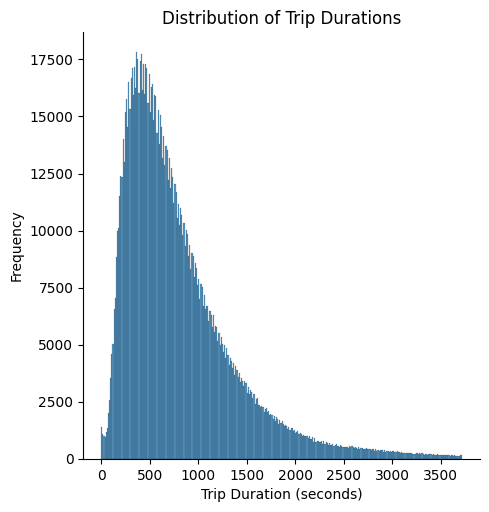

In [22]:
plt.figure(figsize=(10, 6))
sns.displot(data['trip_duration'], kde=False)
plt.title('Distribution of Trip Durations')
plt.xlabel('Trip Duration (seconds)')
plt.ylabel('Frequency')
plt.show()

<Figure size 1000x600 with 0 Axes>

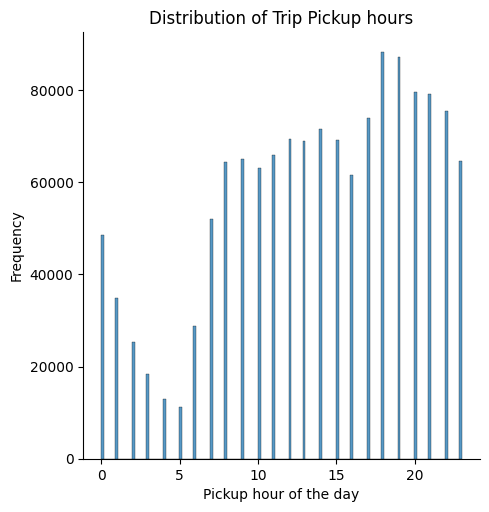

In [23]:
plt.figure(figsize=(10, 6))
sns.displot(data['pickup_hour'], kde=False)
plt.title('Distribution of Trip Pickup hours')
plt.xlabel('Pickup hour of the day')
plt.ylabel('Frequency')
plt.show()

<Figure size 1000x600 with 0 Axes>

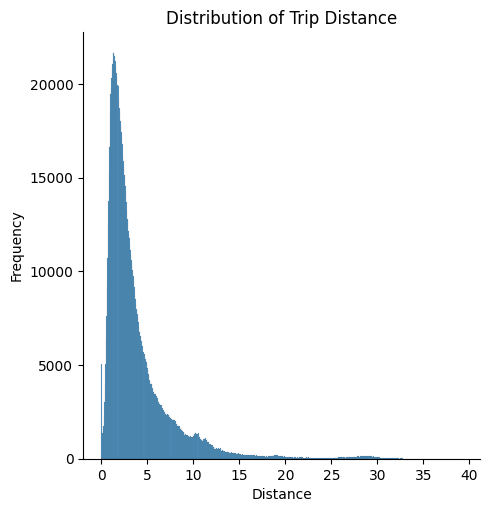

In [24]:
plt.figure(figsize=(10, 6))
sns.displot(data['manhattan_distance'], kde=False)
plt.title('Distribution of Trip Distance')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.show()

## Feature Engineering on Test data

In [25]:
test.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'passenger_count',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'store_and_fwd_flag'],
      dtype='object')

In [26]:
test['pickup_datetime'] = pd.to_datetime(test['pickup_datetime'])
test['pickup_hour'] = test['pickup_datetime'].dt.hour
test['pickup_day_of_week'] = test['pickup_datetime'].dt.dayofweek
test['pickup_month'] = test['pickup_datetime'].dt.month
test['date'] = test['pickup_datetime'].dt.date
test['date']=pd.to_datetime(test['date'])

#encoding categorical columns
categorical_features = ['store_and_fwd_flag','vendor_id']
for feature in categorical_features:
  dummies = pd.get_dummies(test[feature], prefix=feature)
  test = pd.concat([test, dummies], axis=1)
  test.drop([feature], axis=1, inplace=True)

def manhattan_distance(lat_1, lng_1, lat_2, lng_2):
    lat_1, lng_1, lat_2, lng_2 = map(np.radians, (lat_1, lng_1, lat_2, lng_2))
    AVG_EARTH_RADIUS = 6371
    dlat = lat_2 - lat_1
    dlng = lng_2 - lng_1
    lat_dist = AVG_EARTH_RADIUS * dlat
    lng_dist = AVG_EARTH_RADIUS * np.cos((lat_1 + lat_2) / 2) * dlng
    return abs(lat_dist) + abs(lng_dist)

def add_manhattan_distance_feature(df):
    df['manhattan_distance'] = manhattan_distance(df['pickup_latitude'],
                                                   df['pickup_longitude'],
                                                   df['dropoff_latitude'],
                                                   df['dropoff_longitude'])

add_manhattan_distance_feature(test)

def bearing_ft(lat_1, lng_1, lat_2, lng_2):
    lat_1, lng_1, lat_2, lng_2 = map(np.radians, (lat_1, lng_1, lat_2, lng_2))
    dlon = lng_2 - lng_1
    x = np.sin(dlon) * np.cos(lat_2)
    y = np.cos(lat_1) * np.sin(lat_2) - np.sin(lat_1) * np.cos(lat_2) * np.cos(dlon)
    initial_bearing = np.arctan2(x, y)
    initial_bearing = np.degrees(initial_bearing)
    bearing = (initial_bearing + 360) % 360
    return bearing

def add_bearing(df):
    df['bearing'] = bearing_ft(df['pickup_latitude'],
                               df['pickup_longitude'],
                               df['dropoff_latitude'],
                               df['dropoff_longitude'])

add_bearing(test)

# Step 1: Fit KMeans clustering on pickup and dropoff coordinates
# Create a combined dataset of coordinates for clustering
coords = np.vstack((test[['pickup_latitude', 'pickup_longitude']].values,
                    test[['dropoff_latitude', 'dropoff_longitude']].values))

# Initialize and fit KMeans
kmeans = KMeans(n_clusters=100, random_state=42)
kmeans.fit(coords)

# Get cluster centers
cluster_centers = kmeans.cluster_centers_

# Step 2: Compute distances to each cluster center for pickup and dropoff points

# Calculate distances for pickup and dropoff points
pickup_distances = cdist(test[['pickup_latitude', 'pickup_longitude']], cluster_centers)
dropoff_distances = cdist(test[['dropoff_latitude', 'dropoff_longitude']], cluster_centers)

# Combine pickup and dropoff distances into a single array (200 columns in total)
distances = np.hstack([pickup_distances, dropoff_distances])

# Step 3: Apply PCA to reduce the 200 distance features to 10 principal components
scaler = StandardScaler()
distances_scaled = scaler.fit_transform(distances)  # Scale data for PCA
pca = PCA(n_components=10, random_state=42)
pca_distances = pca.fit_transform(distances_scaled)

# Convert PCA components into a DataFrame and add to the main dataset
pca_columns = [f'pca_component_{i+1}' for i in range(10)]
pca_distances_df = pd.DataFrame(pca_distances, columns=pca_columns)
test = pd.concat([test.reset_index(drop=True), pca_distances_df], axis=1)

test['rush_hour'] = np.where(
    ((test['pickup_hour'] >= 7) & (test['pickup_hour'] < 9)) |
    ((test['pickup_hour'] >= 17) & (test['pickup_hour'] < 19)),
    1,
    0
)

holidays_list = [
    "Jan-01", "Jan-18", "Feb-12", "Feb-15", "May-08", "May-30",
    "Jun-19", "Jul-04", "Sep-05", "Oct-10", "Nov-11", "Nov-24",
    "Dec-25", "Dec-26", "Dec-31", "Jul-04", "Nov-08"
]
test['pickup_datetime'] = pd.to_datetime(test['pickup_datetime'])
test['holidays'] = np.where(test['pickup_datetime'].dt.strftime('%b-%d').isin(holidays_list), 1, 0)

# Define pickup and dropoff coordinates
coords = test[['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']]

# Configure KNN with K values 15, 30, and 45
knn_values = [15, 30, 45]

# Store KNN-based average distances
for k in knn_values:
    knn_model = NearestNeighbors(n_neighbors=k, algorithm='ball_tree')
    knn_model.fit(coords)

    # Find the K nearest neighbors
    distances, _ = knn_model.kneighbors(coords)

    # Calculate average distance to the K nearest neighbors for each trip
    avg_distance = distances.mean(axis=1)

    # Add this as a new feature
    test[f'knn_{k}_avg_distance'] = avg_distance

test = pd.merge(test, data_weather, on='date', how='left')
test['snow fall'] = test['snow fall'].replace('T', 0.01)
test['snow depth'] = test['snow depth'].replace('T', 0)
test['precipitation'] =test['precipitation'].replace('T', 0.001)

/opt/homebrew/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [27]:
print(data.dtypes)

id                              object
pickup_datetime         datetime64[ns]
dropoff_datetime        datetime64[ns]
passenger_count                  int64
pickup_longitude               float64
pickup_latitude                float64
dropoff_longitude              float64
dropoff_latitude               float64
trip_duration                    int64
pickup_hour                      int32
pickup_day_of_week               int32
pickup_month                     int32
store_and_fwd_flag_N              bool
store_and_fwd_flag_Y              bool
vendor_id_1                       bool
vendor_id_2                       bool
manhattan_distance             float64
bearing                        float64
avg_speed                      float64
pca_component_1                float64
pca_component_2                float64
pca_component_3                float64
pca_component_4                float64
pca_component_5                float64
pca_component_6                float64
pca_component_7          

## Modelling with XGBoost

### Training the model

In [28]:
import xgboost as xgb

def preprocess_data(data, is_train=True):
    """Preprocesses the data by dropping unnecessary columns and converting datetime."""
    # Define columns to drop
    drop_cols = ['avg_speed', 'trip_duration', 'dropoff_datetime','date']

    if is_train:
        drop_cols.append('id')  # Drop 'id' in training only
        y = data["trip_duration"]
        X = data.drop(drop_cols, axis=1)
        X['pickup_datetime'] = X['pickup_datetime'].astype('int64') // 10**9  # Convert datetime to Unix timestamp
        X['snow fall'] = X['snow fall'].astype(float)
        X['snow depth'] = X['snow depth'].astype(int)
        X['precipitation'] = X['precipitation'].astype(float)
        return X, y
    else:
        # Ensure no rows are dropped; handle columns not present safely
        X = data.drop(columns=[col for col in drop_cols if col in data.columns], errors='ignore')
        X['pickup_datetime'] = X['pickup_datetime'].astype('int64') // 10**9
        X['snow fall'] = X['snow fall'].astype(float)
        X['snow depth'] = X['snow depth'].astype(int)
        X['precipitation'] = X['precipitation'].astype(float)
        return X

def evaluate_model(y_true, y_pred):
    """Calculates and prints MAE, MSE, and RMSE."""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    print(f"MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}")
    return mae, mse, rmse

def calculate_baseline(y_train, y_val):
    """Calculates baseline MAE and RMSE using the mean as a naive predictor."""
    baseline_pred = y_train.mean()
    baseline_mae = mean_absolute_error(y_val, [baseline_pred] * len(y_val))
    baseline_rmse = mean_squared_error(y_val, [baseline_pred] * len(y_val), squared=False)
    print(f"Baseline MAE: {baseline_mae:.2f}, Baseline RMSE: {baseline_rmse:.2f}")
    return baseline_mae, baseline_rmse

# Preprocess the data
X, y = preprocess_data(data)

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Defining the parameter grid for RandomizedSearchCV
param_dist = {
    'learning_rate': np.linspace(0.05, 0.2, 4),  # Reduced range
    'max_depth': [6, 7, 8],  # Reduced depth range
    'n_estimators': [100, 150, 200],
    'subsample': [0.8, 0.9, 1.0],  # Reduced subsample range
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha': [0.05, 0.1, 0.2],  # Regularization parameter
    'reg_lambda': [0.5, 1.0, 1.5]  # Regularization parameter
}

# Initializing the XGBoost model
xgb_model = XGBRegressor(objective='reg:squarederror', eval_metric='rmse')

# Using RandomizedSearchCV instead of GridSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=50,  # Limit iterations to 50 for faster search
    scoring='neg_mean_squared_error',
    cv=3,  # Reduced folds for faster execution to 3-fold
    verbose=2,
    n_jobs=-1,
    random_state=42
)

# Fit the model using randomized search
random_search.fit(X_train, y_train)

# Best parameters and score from the search
print(f"Best parameters: {random_search.best_params_}")
print(f"Best score (negative MSE): {-random_search.best_score_}")

# Evaluate the model using the best found parameters
model = random_search.best_estimator_
y_pred = model.predict(X_val)
evaluate_model(y_val, y_pred)

# Calculate baseline metrics for comparison
calculate_baseline(y_train, y_val)

Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV] END colsample_bytree=0.8, learning_rate=0.15000000000000002, max_depth=8, n_estimators=100, reg_alpha=0.2, reg_lambda=1.0, subsample=0.8; total time=   8.8s
[CV] END colsample_bytree=0.8, learning_rate=0.15000000000000002, max_depth=8, n_estimators=100, reg_alpha=0.2, reg_lambda=1.0, subsample=0.8; total time=   9.1s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=8, n_estimators=100, reg_alpha=0.05, reg_lambda=1.5, subsample=1.0; total time=   9.1s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=8, n_estimators=100, reg_alpha=0.05, reg_lambda=1.5, subsample=1.0; total time=   9.1s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=8, n_estimators=100, reg_alpha=0.05, reg_lambda=1.5, subsample=1.0; total time=   9.2s
[CV] END colsample_bytree=0.8, learning_rate=0.15000000000000002, max_depth=8, n_estimators=100, reg_alpha=0.2, reg_lambda=1.0, subsample=0.8; total time=  10.9s
[CV] END co

/opt/homebrew/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:700: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=8, n_estimators=200, reg_alpha=0.2, reg_lambda=1.5, subsample=0.9; total time=  17.2s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=8, n_estimators=200, reg_alpha=0.2, reg_lambda=1.5, subsample=0.9; total time=  19.2s
[CV] END colsample_bytree=0.7, learning_rate=0.2, max_depth=8, n_estimators=150, reg_alpha=0.2, reg_lambda=1.5, subsample=0.8; total time=  12.5s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=8, n_estimators=200, reg_alpha=0.2, reg_lambda=1.5, subsample=0.9; total time=  20.6s
[CV] END colsample_bytree=1.0, learning_rate=0.15000000000000002, max_depth=8, n_estimators=100, reg_alpha=0.05, reg_lambda=0.5, subsample=0.8; total time=  10.0s
[CV] END colsample_bytree=0.7, learning_rate=0.2, max_depth=8, n_estimators=150, reg_alpha=0.2, reg_lambda=1.5, subsample=0.8; total time=  12.8s
[CV] END colsample_bytree=0.7, learning_rate=0.2, max_depth=8, n_estimators=150, reg_alpha=0.2, reg_lambda=

(432.5936756225882, 583.2111046426643)

### Predictive Error Analysis


/var/folders/1z/9l74yfvx0j31d5v75zchygwc0000gn/T/ipykernel_7494/1150753453.py:7: RuntimeWarning: overflow encountered in expm1
  errors_original_scale = y_val - np.expm1(y_pred_val)  # Adjust based on actual data transformation


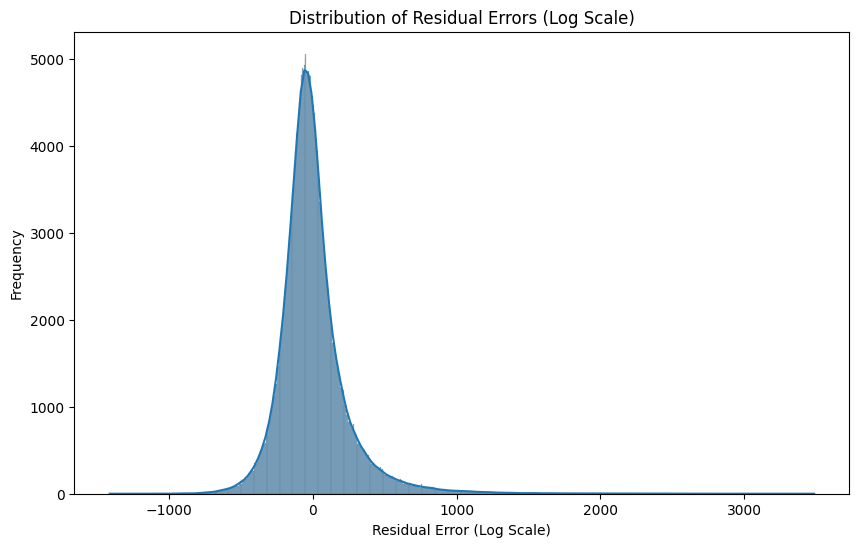

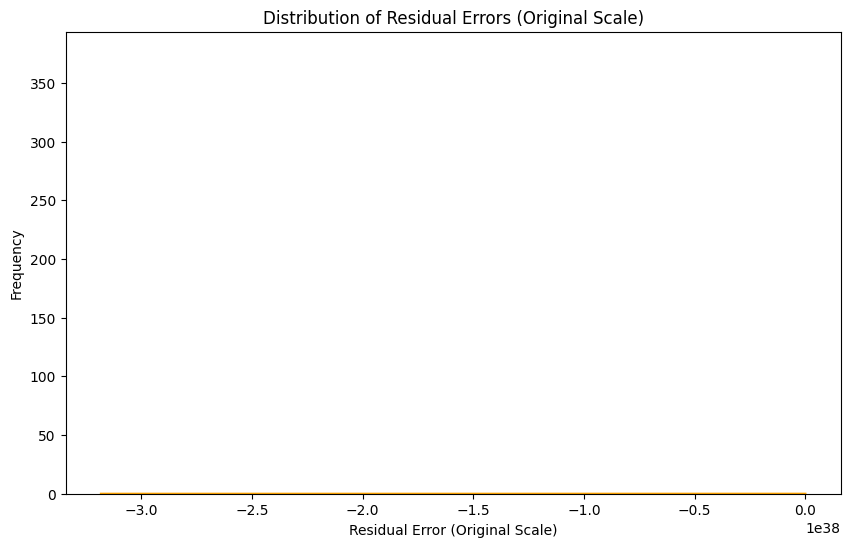

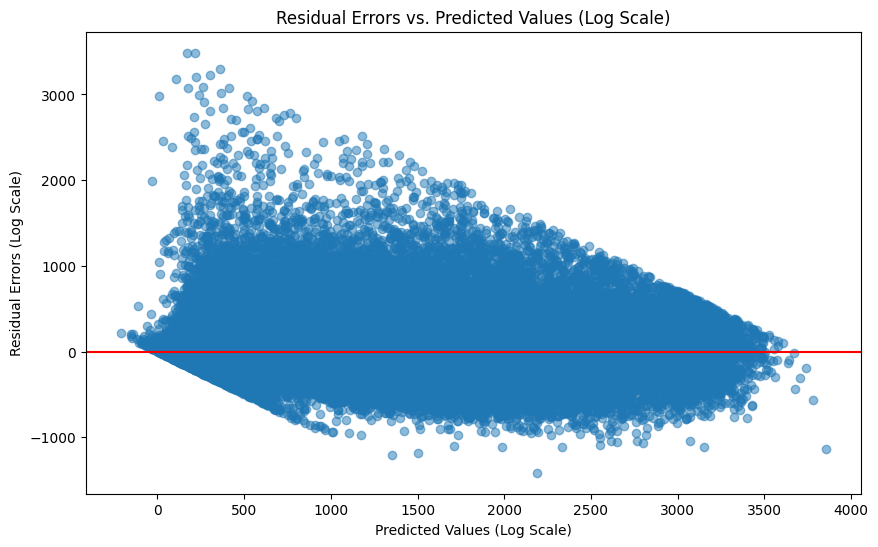

In [29]:
# Step 1: Generate predictions for the validation set
y_pred_val = model.predict(X_val)

# Step 2: Calculate residual errors
# Assuming the target variable was log-transformed in training, adjust if necessary.
errors_log_scale = y_val - y_pred_val
errors_original_scale = y_val - np.expm1(y_pred_val)  # Adjust based on actual data transformation

# Step 3: Visualize residual errors
# Histogram of residual errors in log scale
plt.figure(figsize=(10, 6))
sns.histplot(errors_log_scale, kde=True)
plt.title('Distribution of Residual Errors (Log Scale)')
plt.xlabel('Residual Error (Log Scale)')
plt.ylabel('Frequency')
plt.show()

# Histogram of residual errors in original scale
plt.figure(figsize=(10, 6))
sns.histplot(errors_original_scale, kde=True, color='orange')
plt.title('Distribution of Residual Errors (Original Scale)')
plt.xlabel('Residual Error (Original Scale)')
plt.ylabel('Frequency')
plt.show()

# Scatter plot of residual errors vs. predicted values in log scale
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_val, errors_log_scale, alpha=0.5)
plt.title('Residual Errors vs. Predicted Values (Log Scale)')
plt.xlabel('Predicted Values (Log Scale)')
plt.ylabel('Residual Errors (Log Scale)')
plt.axhline(y=0, color='r', linestyle='-')
plt.show()

### Visualize feature importance

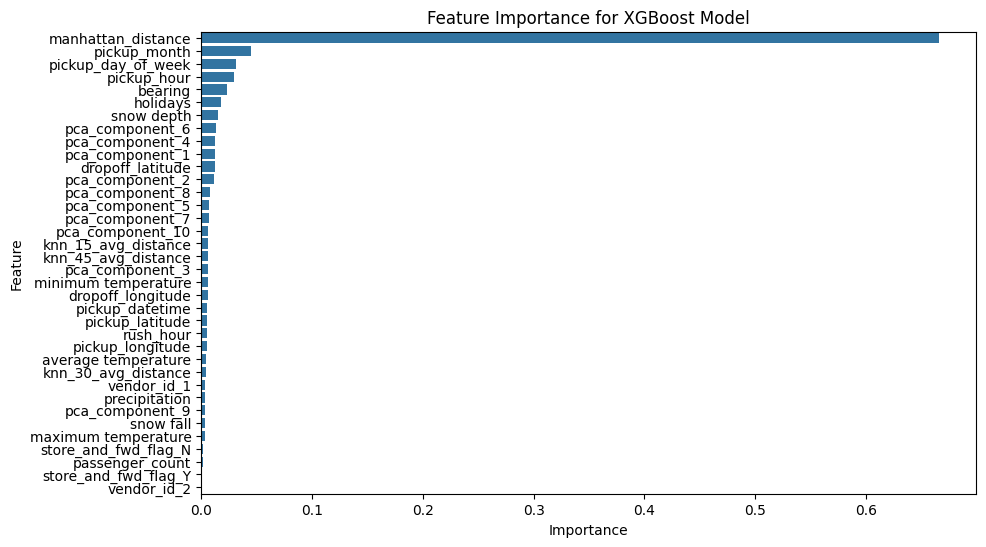

In [30]:
# Visualize feature importance
# Convert feature importances to a DataFrame and plot
importance = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature')
plt.title("Feature Importance for XGBoost Model")
plt.show()

## Prediction and Submission File Creation

In [31]:
# Preprocess the test data
X_test = preprocess_data(test, is_train=False)

# Remove the 'id' column only for prediction
X_test_no_id = X_test.drop(columns=['id'], errors='ignore')

# Make predictions
y_pred_test = model.predict(X_test_no_id)

# Create a DataFrame for the submission file
submission = pd.DataFrame({'id': test['id'], 'trip_duration': y_pred_test})
submission.to_csv('/Users/iliadioleti/Downloads/Dataset/submission.csv', index=False)
submission.head()

,id,trip_duration
0,id3004672,909.910461
1,id3505355,794.316528
2,id1217141,487.648132
3,id2150126,1176.991455
4,id1598245,469.343231
